# Pragmatic naming experiment comparison

The accuracy of Naming Understandability Scores assigned by the pragmatic evaluator is compared across models and between GPT-5.6 Luna runs with and without the Context Description.

In [39]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from pymongo import MongoClient

EXPERIMENTS = {
    "pragmatic-context-gpt5-6-luna": "GPT-5.6 Luna (with context)",
    "pragmatic-no-context-gpt5-6-luna": "GPT-5.6 Luna (without context)",
    "glm-5-3-flash-naming-context": "GLM-5.3 Flash",
    "qwen3-8-flash-naming-context": "Qwen3-8 Flash",
    "gemini-3-5-flash-lite-naming-context": "Gemini 3.5 Flash Lite",
}
MODEL_COLORS = {
    "GPT-5.6 Luna (with context)": "#1f77b4",
    "GPT-5.6 Luna (without context)": "#17becf",
    "GLM-5.3 Flash": "#ff7f0e",
    "Qwen3-8 Flash": "#9467bd",
    "Gemini 3.5 Flash Lite": "#d62728",
}
COLLECTION_NAME = "pragmatic_naming_eval"
MONGODB_URI = os.getenv(
    "MONGODB_URI",
    "mongodb://127.0.0.1:27017/llm_uml_evaluator?replicaSet=rs0",
)

FIGURES_DIR = Path("eval/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

## Data loading

The URI is read from the `MONGODB_URI` environment variable. JupyterLab is started with `uv run --env-file .env --group eval jupyter lab`.

In [40]:
client = MongoClient(MONGODB_URI, serverSelectionTimeoutMS=5_000)
try:
    collection = client.get_default_database()[COLLECTION_NAME]
    documents = list(
        collection.find(
            {"experiment_name": {"$in": list(EXPERIMENTS)}},
            {
                "experiment_name": 1,
                "sample": 1,
                "mutation": 1,
                "nodes": 1,
            },
        )
    )
finally:
    client.close()

loaded_experiments = {document["experiment_name"] for document in documents}
if missing := set(EXPERIMENTS).difference(loaded_experiments):
    raise ValueError(f"No observations found for: {sorted(missing)}")

pd.Series(
    (document["experiment_name"] for document in documents),
    name="experiment_name",
).value_counts().rename("observations")

experiment_name
pragmatic-context-gpt5-6-luna           120
pragmatic-no-context-gpt5-6-luna        120
qwen3-8-flash-naming-context            120
gemini-3-5-flash-lite-naming-context    120
glm-5-3-flash-naming-context            120
Name: observations, dtype: int64

## Metric calculation

A classification pair contains a node UID and its Naming Understandability Score:

- `TP`: the returned score for a node is the expected score;
- `FP`: the returned node-score pair is not expected;
- `FN`: the expected node-score pair was not returned.

```text
Precision = TP / (TP + FP)
Recall    = TP / (TP + FN)
F1        = 2TP / (2TP + FP + FN)
```

Each node has one expected and one returned score, so a wrong score contributes one FP and one FN. Therefore `FP = FN`, precision, recall, and F1 are identical, and the formula simplifies to:

```text
F1 = TP / (TP + FN) = correctly scored nodes / all nodes
```

Only F1 is retained because the other two metrics carry the same information.

In [41]:
df = pd.json_normalize(documents).rename(
    columns={
        "nodes.true_positive": "tp",
        "nodes.false_positive": "fp",
        "nodes.false_negative": "fn",
    }
)

required_columns = {
    "experiment_name", "sample", "mutation", "tp", "fp", "fn"
}
if missing := required_columns.difference(df.columns):
    raise ValueError(f"Missing columns: {sorted(missing)}")

df["model"] = df["experiment_name"].map(EXPERIMENTS)
f1_denominator = 2 * df["tp"] + df["fp"] + df["fn"]
df["f1"] = 2 * df["tp"] / f1_denominator.where(
    f1_denominator.ne(0)
)
df["all_nodes_correct"] = df["fp"].eq(0) & df["fn"].eq(0)

df[
    [
        "experiment_name",
        "sample",
        "mutation",
        "model",
        "f1",
        "all_nodes_correct",
    ]
].head()

,experiment_name,sample,mutation,model,f1,all_nodes_correct
0,pragmatic-context-gpt5-6-luna,1,0,GPT-5.6 Luna (with context),1.0,True
1,pragmatic-context-gpt5-6-luna,1,0,GPT-5.6 Luna (with context),1.0,True
2,pragmatic-context-gpt5-6-luna,1,0,GPT-5.6 Luna (with context),1.0,True
3,pragmatic-context-gpt5-6-luna,1,1,GPT-5.6 Luna (with context),1.0,True
4,pragmatic-context-gpt5-6-luna,1,1,GPT-5.6 Luna (with context),1.0,True


## Coverage check

The table shows the number of repetitions for each `model × sample × mutation` combination.

In [42]:
coverage = (
    df.groupby(["model", "sample", "mutation"], sort=False)
    .size()
    .unstack(fill_value=0)
)
display(coverage)
display(
    df.groupby(["model", "mutation"], sort=False)["f1"]
    .agg(["mean", "std", "count"])
    .round(3)
)

mutation                               0  1  2  3
model                          sample            
GPT-5.6 Luna (with context)    1       3  3  3  3
                               2       3  3  3  3
                               3       3  3  3  3
                               4       3  3  3  3
                               5       3  3  3  3
                               6       3  3  3  3
                               7       3  3  3  3
                               8       3  3  3  3
                               9       3  3  3  3
                               10      3  3  3  3
GPT-5.6 Luna (without context) 1       3  3  3  3
                               2       3  3  3  3
                               3       3  3  3  3
                               4       3  3  3  3
                               5       3  3  3  3
                               6       3  3  3  3
                               7       3  3  3  3
                               8       3  3  3  3
                               9       3  3  3  3
                               10      3  3  3  3
Qwen3-8 Flash                  1       3  3  3  3
                               2       3  3  3  3
                               3       3  3  3  3
                               4       3  3  3  3
                               5       3  3  3  3
                               6       3  3  3  3
                               7       3  3  3  3
                               8       3  3  3  3
                               9       3  3  3  3
                               10      3  3  3  3
Gemini 3.5 Flash Lite          1       3  3  3  3
                               2       3  3  3  3
                               3       3  3  3  3
                               4       3  3  3  3
                               5       3  3  3  3
                               6       3  3  3  3
                               7       3  3  3  3
                               8       3  3  3  3
                               9       3  3  3  3
                               10      3  3  3  3
GLM-5.3 Flash                  1       3  3  3  3
                               2       3  3  3  3
                               3       3  3  3  3
                               4       3  3  3  3
                               5       3  3  3  3
                               6       3  3  3  3
                               7       3  3  3  3
                               8       3  3  3  3
                               9       3  3  3  3
                               10      3  3  3  3

mean    std  count
model                          mutation                     
GPT-5.6 Luna (with context)    0         0.995  0.015     30
                               1         0.996  0.016     30
                               2         0.991  0.025     30
                               3         0.993  0.025     30
GPT-5.6 Luna (without context) 0         0.851  0.103     30
                               1         0.959  0.047     30
                               2         0.937  0.063     30
                               3         0.938  0.072     30
Qwen3-8 Flash                  0         0.965  0.059     30
                               1         0.964  0.063     30
                               2         0.943  0.071     30
                               3         0.948  0.069     30
Gemini 3.5 Flash Lite          0         0.998  0.011     30
                               1         0.998  0.011     30
                               2         0.967  0.050     30
                               3         0.984  0.029     30
GLM-5.3 Flash                  0         0.968  0.068     30
                               1         0.978  0.058     30
                               2         0.977  0.034     30
                               3         0.983  0.047     30

## Model comparison by mutation

Mean F1 and the rate of observations with all nodes correct are shown for every model.

In [43]:
f1_comparison = (
    df.groupby(["mutation", "model"], sort=False)["f1"]
    .mean()
    .unstack()
    .reindex(columns=EXPERIMENTS.values())
)
all_correct_comparison = (
    df.groupby(["mutation", "model"], sort=False)["all_nodes_correct"]
    .mean()
    .unstack()
    .reindex(columns=EXPERIMENTS.values())
)
comparison = pd.concat(
    {"F1": f1_comparison, "All nodes correct rate": all_correct_comparison},
    axis=1,
)
comparison.style.format(
    {
        ("F1", column): "{:.3f}"
        for column in EXPERIMENTS.values()
    }
    | {
        ("All nodes correct rate", column): "{:.1%}"
        for column in EXPERIMENTS.values()
    }
)

## Quality by mutation

Bars show mean F1 for each model; error bars span the minimum and maximum F1 observed across repetitions.

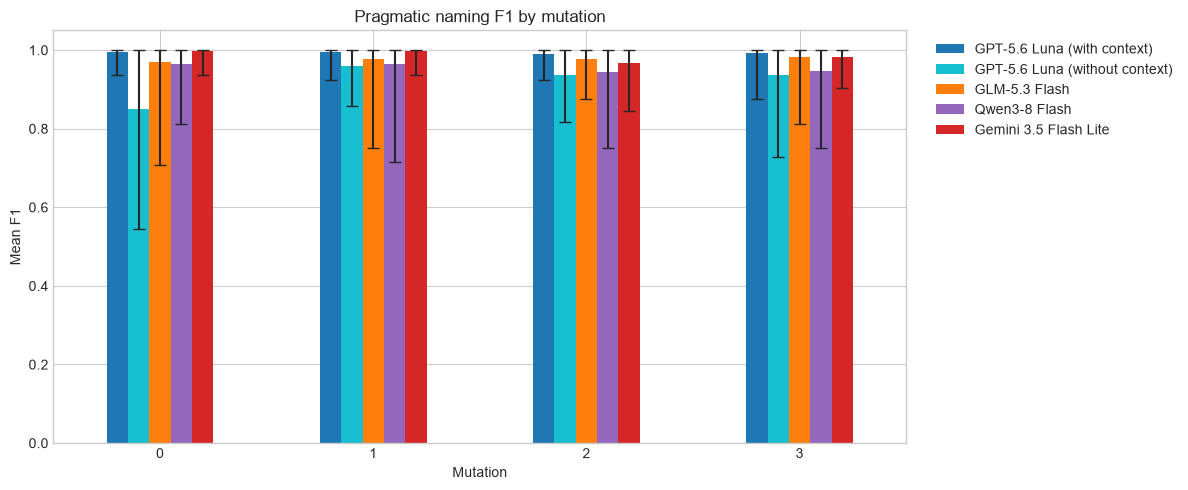

In [44]:
f1_by_mutation = df.groupby(["model", "mutation"], sort=False)["f1"].agg(
    ["mean", "min", "max"]
)
ylim = (0, 1.05)

f1_means = (
    f1_by_mutation["mean"]
    .unstack("model")
    .reindex(columns=EXPERIMENTS.values())
)
f1_mins = (
    f1_by_mutation["min"]
    .unstack("model")
    .reindex(columns=EXPERIMENTS.values())
)
f1_maxs = (
    f1_by_mutation["max"]
    .unstack("model")
    .reindex(columns=EXPERIMENTS.values())
)
errors = {
    model: [
        (f1_means[model] - f1_mins[model]).to_numpy(),
        (f1_maxs[model] - f1_means[model]).to_numpy(),
    ]
    for model in f1_means
}
fig, ax = plt.subplots(figsize=(12, 5))
f1_means.plot.bar(
    ax=ax,
    yerr=errors,
    capsize=4,
    rot=0,
    color=[MODEL_COLORS[model] for model in f1_means],
)
ax.set(
    title="Pragmatic naming F1 by mutation",
    xlabel="Mutation",
    ylabel="Mean F1",
    ylim=ylim,
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

### Save figure

In [ ]:
fig.savefig(
    FIGURES_DIR / "pragmatic_f1_by_mutation.png",
    dpi=300,
    bbox_inches="tight",
)

## All nodes correct rate

An observation counts as correct only when every evaluated node receives the expected Naming Understandability Score.

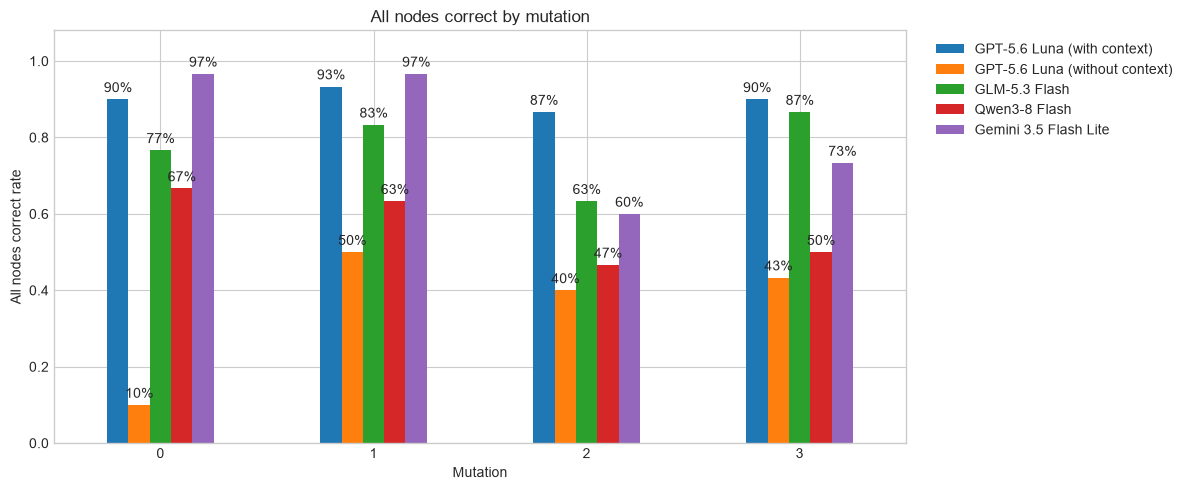

In [7]:
all_correct_by_mutation = (
    df.groupby(["mutation", "model"], sort=False)["all_nodes_correct"]
    .mean()
    .unstack("model")
    .reindex(columns=EXPERIMENTS.values())
)

fig, ax = plt.subplots(figsize=(12, 5))
all_correct_by_mutation.plot.bar(
    ax=ax,
    rot=0,
    color=[MODEL_COLORS[model] for model in all_correct_by_mutation],
)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{value:.0%}" for value in container.datavalues],
        padding=3,
    )
ax.set(
    title="All nodes correct by mutation",
    xlabel="Mutation",
    ylabel="All nodes correct rate",
    ylim=(0, 1.08),
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

### Save figure

In [ ]:
fig.savefig(
    FIGURES_DIR / "pragmatic_all_nodes_correct.png",
    dpi=300,
    bbox_inches="tight",
)